In [ ]:
import shutil
import os
import urllib.request
from unittest.mock import inplace
import pandas as pd
from pathlib import Path
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sphinx.addnodes import index
from sqlalchemy.dialects.mssql.information_schema import columns
from tensorflow.python.layers.core import dropout

## Get Data

Train

In [2]:
folder = "Data"
url = 'https://dcapswoz.ict.usc.edu/wwwdaicwoz/train_split_Depression_AVEC2017.csv'
output = os.path.join(folder, "train.csv")
urllib.request.urlretrieve(url, output)
labels = pd.read_csv('Data/train.csv')

In [11]:
for label in labels['Participant_ID']:
    file_path = Path(f'Data/train/{label}_P.zip')
    folder_path = Path(f'Data/train/{label}_P')
    if file_path.exists() or folder_path.exists():
        continue
    url = f'https://dcapswoz.ict.usc.edu/wwwdaicwoz/{label}_P.zip'
    folder = "Data/train"
    output = os.path.join(folder, f'{label}_P.zip')
    urllib.request.urlretrieve(url, output)
    print(label)

In [ ]:
for label in labels['Participant_ID']:
    file_path = Path(f'Data/train/{label}_P.zip')
    folder_path = Path(f'Data/train/{label}_P')
    with zipfile.ZipFile(file_path) as z:
        z.extractall(folder_path)
    file_path.unlink()

Test

In [3]:
folder = "Data"
url = 'https://dcapswoz.ict.usc.edu/wwwdaicwoz/dev_split_Depression_AVEC2017.csv'
output = os.path.join(folder, "dev.csv")
urllib.request.urlretrieve(url, output)
label_dev = pd.read_csv('Data/dev.csv')

In [144]:
for label in label_dev['Participant_ID']:
    file_path = f'Data/test/{label}_P.zip'
    if os.path.isfile(file_path):
        continue
    url = f'https://dcapswoz.ict.usc.edu/wwwdaicwoz/{label}_P.zip'
    folder = "Data/test"
    output = os.path.join(folder, f'{label}_P.zip')
    urllib.request.urlretrieve(url, output)
    print(label)

In [145]:
for label in label_dev['Participant_ID']:
    file_path = Path(f'Data/test/{label}_P.zip')
    folder_path = Path(f'Data/test/{label}_P')
    with zipfile.ZipFile(file_path) as z:
        z.extractall(folder_path)
    file_path.unlink()

See Data

In [208]:
df = pd.read_csv("Data/train/303_P/303_TRANSCRIPT.csv", sep = "\t")

In [209]:
df["value"].str.len()

0      353
1       23
2       23
3       16
4       29
      ... 
186     44
187     40
188     44
189      9
190      7
Name: value, Length: 191, dtype: int64

In [210]:
df.head()

,start_time,stop_time,speaker,value
0,26.276,48.696,Ellie,hi i'm ellie thanks for coming in today i was ...
1,49.256,50.406,Ellie,how are you doing today
2,50.686,51.836,Participant,okay how 'bout yourself
3,52.576,54.136,Ellie,i'm great thanks
4,54.816,56.236,Ellie,where are you from originally


## Data Preprocessing

In [4]:
df = []
for label in labels['Participant_ID']:
    sample = pd.read_csv(f"Data/train/{label}_P/{label}_TRANSCRIPT.csv", sep = "\t")
    df.append(sample)

In [5]:
df_test = []
for label in label_dev['Participant_ID']:
    sample = pd.read_csv(f"Data/test/{label}_P/{label}_TRANSCRIPT.csv", sep = "\t")
    df_test.append(sample)

In [122]:
df[0]

,start_time,stop_time,speaker,value
0,26.276,48.696,Ellie,hi i'm ellie thanks for coming in today i was ...
1,49.256,50.406,Ellie,how are you doing today
2,50.686,51.836,Participant,okay how 'bout yourself
3,52.576,54.136,Ellie,i'm great thanks
4,54.816,56.236,Ellie,where are you from originally
...,...,...,...,...
186,950.726,953.526,Ellie,okay i think i've asked everything i need to
187,954.266,956.126,Ellie,thanks for sharing your thoughts with me
188,956.126,958.636,Participant,you're more than welcome you have a good day
189,958.656,959.526,Ellie,goodbye


In [6]:
for sample in df:
    sample["total_time"] = sample["stop_time"] - sample["start_time"]
for sample in df_test:
    sample["total_time"] = sample["stop_time"] - sample["start_time"]

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df[0]["speaker"])
for sample in df_test:
    sample["speaker"] = encoder.transform(sample["speaker"])
for sample in df:
    sample["speaker"] = encoder.transform(sample["speaker"])

In [8]:
from sklearn.preprocessing import StandardScaler
Numerics = []
for sample in df:
    Numerics.append(sample.loc[:,["start_time", "stop_time", "total_time"]])
Numerics = pd.concat(Numerics)
scale = StandardScaler()
scale.fit(Numerics)

,copy,True
,with_mean,True
,with_std,True


In [9]:
for sample in df:
    sample.loc[:,["start_time", "stop_time", "total_time"]] = scale.transform(sample.loc[:,["start_time", "stop_time", "total_time"]])
for sample in df_test:
    sample.loc[:,["start_time", "stop_time", "total_time"]] = scale.transform(sample.loc[:,["start_time", "stop_time", "total_time"]])

In [11]:
df[0]

,start_time,stop_time,speaker,value,total_time
0,-1.461682,-1.397615,0,hi i'm ellie thanks for coming in today i was ...,8.010009
1,-1.388480,-1.392169,0,how are you doing today,-0.502014
2,-1.383925,-1.387615,1,okay how 'bout yourself,-0.502014
3,-1.377904,-1.380290,0,i'm great thanks,-0.337937
4,-1.370769,-1.373602,0,where are you from originally,-0.393963
...,...,...,...,...,...
186,1.483136,1.484069,0,okay i think i've asked everything i need to,0.158298
187,1.494413,1.492350,0,thanks for sharing your thoughts with me,-0.217880
188,1.500338,1.500344,1,you're more than welcome you have a good day,0.042243
189,1.508397,1.503178,0,goodbye,-0.614067


In [12]:
max_length = []
avg_length = []
for sample in df:
    max_length.append(sample['value'].str.len().max())
    avg_length.append(np.average(sample['value'].str.len()))

<Axes: >

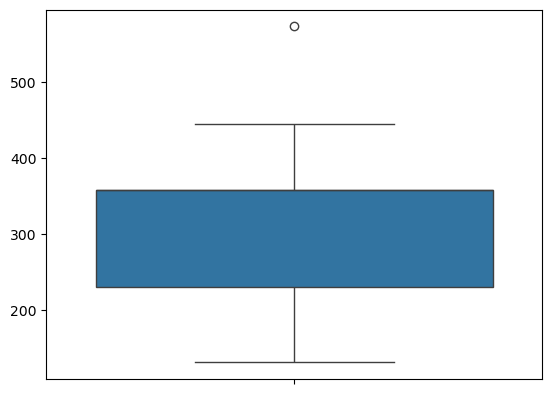

In [13]:
plt.style.use('default')
sns.boxplot(max_length)

<Axes: >

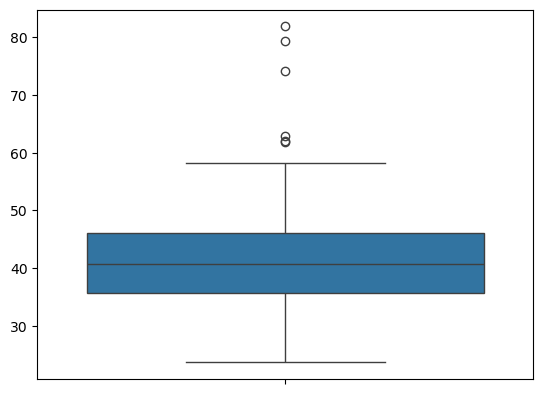

In [14]:
sns.boxplot(avg_length)

In [10]:
from transformers import BertTokenizer, BertModel
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()
model = model.to(device)

def convert(text):
    text = str(text)
    tokens = tokenizer(
    text,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=256
    )
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        res = model(**tokens)
    return res.last_hidden_state[:, 0, :].detach().cpu().numpy()

cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


solve NaN's

In [11]:
for i,sample in enumerate(df):
    if sum(sample.isna().sum()) != 0 :
        print(i)
        sample.dropna(inplace=True)
for i,sample in enumerate(df_test):
    if sum(sample.isna().sum()) != 0 :
        print(i)
        sample.dropna(inplace=True)

5
63
64
7
27


In [12]:
i = 1
for sample in df:
    print(f'Sample {i}')
    i += 1
    sample['value'] = sample['value'].apply(convert)

Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Sample 8
Sample 9
Sample 10
Sample 11
Sample 12
Sample 13
Sample 14
Sample 15
Sample 16
Sample 17
Sample 18
Sample 19
Sample 20
Sample 21
Sample 22
Sample 23
Sample 24
Sample 25
Sample 26
Sample 27
Sample 28
Sample 29
Sample 30
Sample 31
Sample 32
Sample 33
Sample 34
Sample 35
Sample 36
Sample 37
Sample 38
Sample 39
Sample 40
Sample 41
Sample 42
Sample 43
Sample 44
Sample 45
Sample 46
Sample 47
Sample 48
Sample 49
Sample 50
Sample 51
Sample 52
Sample 53
Sample 54
Sample 55
Sample 56
Sample 57
Sample 58
Sample 59
Sample 60
Sample 61
Sample 62
Sample 63
Sample 64
Sample 65
Sample 66
Sample 67
Sample 68
Sample 69
Sample 70
Sample 71
Sample 72
Sample 73
Sample 74
Sample 75
Sample 76
Sample 77
Sample 78
Sample 79
Sample 80
Sample 81
Sample 82
Sample 83
Sample 84
Sample 85
Sample 86
Sample 87
Sample 88
Sample 89
Sample 90
Sample 91
Sample 92
Sample 93
Sample 94
Sample 95
Sample 96
Sample 97
Sample 98
Sample 99
Sample 100
Sample 1

In [13]:
i = 1
for sample in df_test:
    print(f'Sample {i}')
    i += 1
    sample['value'] = sample['value'].apply(convert)

Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Sample 8
Sample 9
Sample 10
Sample 11
Sample 12
Sample 13
Sample 14
Sample 15
Sample 16
Sample 17
Sample 18
Sample 19
Sample 20
Sample 21
Sample 22
Sample 23
Sample 24
Sample 25
Sample 26
Sample 27
Sample 28
Sample 29
Sample 30
Sample 31
Sample 32
Sample 33
Sample 34
Sample 35


In [18]:
length = [len(sample) for sample in df]
print(np.average(length))
print(max(length))

238.30841121495328
473


In [14]:
feed_x = []
feed_x2 = []
for sample in df:
    single = np.array([
        np.concatenate([
            np.array([t, s], dtype=np.float32),
            np.asarray(v, dtype=np.float32).ravel()
        ])
        for t, s, v in zip(sample['total_time'], sample['speaker'], sample['value'])
    ], dtype=np.float32)
    feed_x.append(single)
for sample in df_test:
    single = np.array([
        np.concatenate([
            np.array([t, s], dtype=np.float32),
            np.asarray(v, dtype=np.float32).ravel()
        ])
        for t, s, v in zip(sample['total_time'], sample['speaker'], sample['value'])
    ], dtype=np.float32)
    feed_x2.append(single)

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train = pad_sequences(
    feed_x,
    maxlen=473,
    padding='post',      # zeros added at END of each sample
    truncating='post',   # if truncating needed, cut from END
    dtype='float32'
)
X_test = pad_sequences(
    feed_x2,
    maxlen=473,
    padding='post',      # zeros added at END of each sample
    truncating='post',   # if truncating needed, cut from END
    dtype='float32'
)

In [16]:
y_train = labels['PHQ8_Binary'].values
y_test = label_dev['PHQ8_Binary'].values

In [85]:
from tensorflow.keras.layers import Masking, Bidirectional, LSTM, Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    # Masking layer reads the padded zeros and tells LSTM to ignore them
    Masking(mask_value=0.0, input_shape=(473, 770)),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train, y_train, epochs=40, batch_size=4, validation_split=0.25)

Epoch 1/40


D:\Softwears\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step - accuracy: 0.6625 - loss: 0.6912 - val_accuracy: 0.8889 - val_loss: 0.3743
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.6625 - loss: 0.6346 - val_accuracy: 0.8889 - val_loss: 0.5100
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step - accuracy: 0.6625 - loss: 0.6326 - val_accuracy: 0.8889 - val_loss: 0.4439
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 280ms/step - accuracy: 0.6625 - loss: 0.6242 - val_accuracy: 0.8889 - val_loss: 0.3864
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.6625 - loss: 0.6113 - val_accuracy: 0.8889 - val_loss: 0.4752
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 306ms/step - accuracy: 0.6625 - loss: 0.6252 - val_accuracy: 0.8889 - val_loss: 0.3681
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - accuracy: 0.6625 - loss: 0.6290 - val_accuracy: 0.8889 - val_loss: 0.4475
Epoch 8/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.6625 - loss: 0.6141 - val_accuracy: 0.8889 - val

In [86]:
pred_reg = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step


In [103]:
pred = [1 if i > 0.05 else 0 for i in pred_reg]

In [104]:
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(pred,y_test))
print(confusion_matrix(y_test,pred))

0.6857142857142857
[[16  7]
 [ 4  8]]


In [195]:
from tensorflow.keras.layers import Masking, Bidirectional, LSTM, Dense, Conv1D, MaxPooling1D, Dropout
from tensorflow.keras.models import Sequential

model2 = Sequential([
    # Masking layer reads the padded zeros and tells LSTM to ignore them
    Masking(mask_value=0.0, input_shape=(473, 770)),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model2.fit(X_train, y_train, epochs=40, batch_size=4, validation_split=0.2)

Epoch 1/40


D:\Softwears\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
D:\Softwears\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'conv1d_5' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.6706 - loss: 0.6657 - val_accuracy: 0.9091 - val_loss: 0.3994
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6706 - loss: 0.6517 - val_accuracy: 0.9091 - val_loss: 0.4568
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6706 - loss: 0.6260 - val_accuracy: 0.9091 - val_loss: 0.4231
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6706 - loss: 0.6196 - val_accuracy: 0.9091 - val_loss: 0.4069
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6706 - loss: 0.6218 - val_accuracy: 0.9091 - val_loss: 0.4007
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6706 - loss: 0.6090 - val_accuracy: 0.9091 - val_loss: 0.3666
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6706 - loss: 0.6026 - val_accuracy: 0.8636 - val_loss: 0.4145
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6824 - loss: 0.5975 - val_accuracy: 0.8636 - val_loss: 0.

In [196]:
pred_reg = model2.predict(X_test)

D:\Softwears\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'conv1d_5' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step


In [215]:
pred = [1 if i > 0.5 else 0 for i in pred_reg]

In [216]:
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(pred,y_test))
print(confusion_matrix(y_test,pred))

0.7428571428571429
[[23  0]
 [ 9  3]]


In [118]:
X_train_2d = X_train.reshape(X_train.shape[0] , -1)
X_test_2d = X_test.reshape(X_test.shape[0] , -1)

In [119]:
from sklearn.linear_model import LogisticRegression
model3 = LogisticRegression()
model3.fit(X_train_2d,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [149]:
y_prob = model3.predict_proba(X_test_2d)[:,1]

In [159]:
pred = (y_prob > 0.8).astype(int)
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(pred,y_test))
print(confusion_matrix(y_test,pred))

0.6857142857142857
[[23  0]
 [11  1]]


In [165]:
# Collapse 3D → 2D by averaging across turns
X_2d_train = X_train.mean(axis=1)   # (num_samples, 386)
X_2d_test = X_test.mean(axis=1)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

models = GradientBoostingClassifier()
model.fit(X_2d_train, y_train)
score = model.score(X_2d_test, y_test)
print(f"{name}: {score:.3f}")
pred = model.predict(X_2d_test)
print(accuracy_score(pred,y_test))
print(confusion_matrix(y_test,pred))

Gradient Boost: 0.657
0.6571428571428571
[[19  4]
 [ 8  4]]
